In [52]:
!pip install timm thop

# **Imports**

In [53]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# **Device**

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Image Preprocessing**

In [55]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# **Load Dataset**

In [56]:
data_path = "/kaggle/input/datasets/adithyadiwamjee/train-data/train_data"

dataset = ImageFolder(data_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)

# **Load EfficientNet-B0**

In [57]:
model = timm.create_model("efficientnet_b0", pretrained=True)

model.reset_classifier(30)

model = model.to(device)

# **4.1 Linear Probe**
4.1 Linear Probe

In [58]:
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

# **Loss + Optimizer**

In [59]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# **Training Function**

In [60]:
def train_model(model, train_loader, val_loader, epochs=15):

    train_acc_list=[]
    val_acc_list=[]

    for epoch in range(epochs):

        model.train()

        correct=0
        total=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            preds=outputs.argmax(dim=1)

            correct+=(preds==labels).sum().item()
            total+=labels.size(0)

        train_acc=correct/total
        train_acc_list.append(train_acc)

        model.eval()

        correct=0
        total=0

        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)

                preds=outputs.argmax(dim=1)

                correct+=(preds==labels).sum().item()
                total+=labels.size(0)

        val_acc=correct/total
        val_acc_list.append(val_acc)

        print(epoch+1,train_acc,val_acc)

    return train_acc_list,val_acc_list

# **Train Model**

In [61]:
train_acc,val_acc = train_model(model,train_loader,val_loader)

1 0.6351447979978548 0.7719799857040743
2 0.8144440471934216 0.8055754110078628
3 0.8552020021451555 0.8198713366690493
4 0.876296031462281 0.821300929235168
5 0.8954236682159457 0.8355968548963545
6 0.9097247050411155 0.8305932809149392
7 0.9199141937790489 0.8327376697641172
8 0.9276010010725778 0.827734095782702
9 0.9377904898105113 0.8320228734810579
10 0.9356453342867358 0.8406004288777699
11 0.9440471934215231 0.8420300214438885
12 0.951197711834108 0.8384560400285919
13 0.9558455488022881 0.8313080771979986
14 0.9579907043260636 0.8334524660471766
15 0.9633535931355023 0.8406004288777699


# **Accuracy Plot**

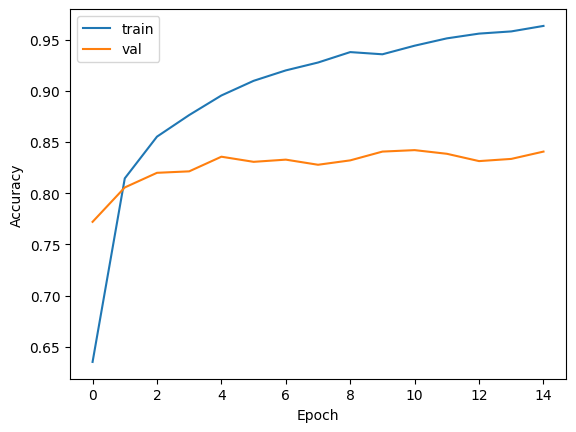

In [62]:
plt.plot(train_acc,label="train")
plt.plot(val_acc,label="val")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

# **Confusion Matrix**

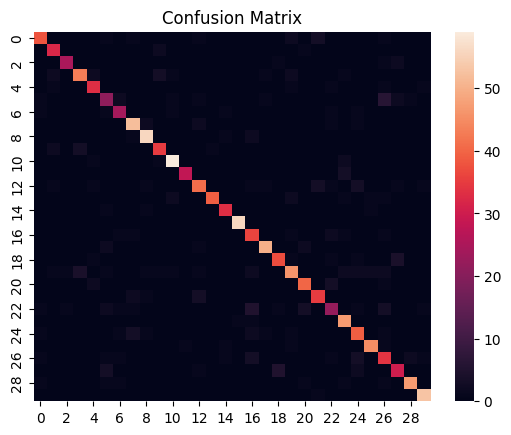

In [63]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        outputs=model(images)

        preds=outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm=confusion_matrix(all_labels,all_preds)

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()

# **Feature Embedding PCA**

In [64]:
features=[]
labels_list=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        feat=model.forward_features(images)

        feat=feat.mean(dim=(2,3))

        features.append(feat.cpu())
        labels_list.append(labels)

features=torch.cat(features)
labels_list=torch.cat(labels_list)

# **PCA Plot**


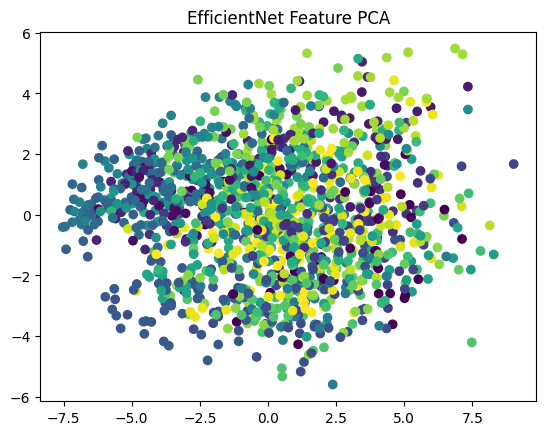

In [65]:
pca=PCA(n_components=2)

reduced=pca.fit_transform(features)

plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)

plt.title("EfficientNet Feature PCA")

plt.show()


 # **4.2 Fine Tuning (Last Block)**
 

In [66]:
model = timm.create_model("efficientnet_b0", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad=False

for param in model.blocks[-1].parameters():
    param.requires_grad=True

for param in model.get_classifier().parameters():
    param.requires_grad=True

train_model(model,train_loader,val_loader)

1 0.04361816231676797 0.04860614724803431
2 0.04772971040400429 0.04503216583273767
3 0.04504826599928495 0.04503216583273767
4 0.04969610296746514 0.04360257326661901
5 0.0470146585627458 0.04932094353109364
6 0.0470146585627458 0.04431736954967834
7 0.045942080800858064 0.04503216583273767
8 0.04629960672148731 0.04646175839885633
9 0.04647836968180193 0.04360257326661901
10 0.04772971040400429 0.04360257326661901
11 0.04719342152306042 0.04217298070050036
12 0.04826599928494816 0.040028591851322376
13 0.047908473364318915 0.04288777698355969
14 0.0446907400786557 0.04431736954967834
15 0.04683589560243118 0.04360257326661901


([0.04361816231676797,
  0.04772971040400429,
  0.04504826599928495,
  0.04969610296746514,
  0.0470146585627458,
  0.0470146585627458,
  0.045942080800858064,
  0.04629960672148731,
  0.04647836968180193,
  0.04772971040400429,
  0.04719342152306042,
  0.04826599928494816,
  0.047908473364318915,
  0.0446907400786557,
  0.04683589560243118],
 [0.04860614724803431,
  0.04503216583273767,
  0.04503216583273767,
  0.04360257326661901,
  0.04932094353109364,
  0.04431736954967834,
  0.04503216583273767,
  0.04646175839885633,
  0.04360257326661901,
  0.04360257326661901,
  0.04217298070050036,
  0.040028591851322376,
  0.04288777698355969,
  0.04431736954967834,
  0.04360257326661901])

# **4.3 Few Shot**

In [67]:
total=len(dataset)

size20=int(0.2*total)
size5=int(0.05*total)

dataset20,_ = random_split(dataset,[size20,total-size20])
dataset5,_ = random_split(dataset,[size5,total-size5])

loader20=DataLoader(dataset20,batch_size=32,shuffle=True)
loader5=DataLoader(dataset5,batch_size=32,shuffle=True)

# **Train 20%**

In [68]:
model = timm.create_model("efficientnet_b0", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_model(model,loader20,val_loader)

1 0.03934191702432046 0.036454610436025735
2 0.0357653791130186 0.03716940671908506
3 0.04220314735336195 0.036454610436025735
4 0.03791130185979971 0.034310221586847746
5 0.029327610872675252 0.035739814152966405
6 0.03791130185979971 0.03359542530378842
7 0.03934191702432046 0.036454610436025735
8 0.03719599427753934 0.035739814152966405
9 0.0357653791130186 0.035025017869907075
10 0.033619456366237484 0.035739814152966405
11 0.0357653791130186 0.032880629020729094
12 0.03791130185979971 0.036454610436025735
13 0.03791130185979971 0.035025017869907075
14 0.03862660944206009 0.0407433881343817
15 0.032904148783977114 0.040028591851322376


([0.03934191702432046,
  0.0357653791130186,
  0.04220314735336195,
  0.03791130185979971,
  0.029327610872675252,
  0.03791130185979971,
  0.03934191702432046,
  0.03719599427753934,
  0.0357653791130186,
  0.033619456366237484,
  0.0357653791130186,
  0.03791130185979971,
  0.03791130185979971,
  0.03862660944206009,
  0.032904148783977114],
 [0.036454610436025735,
  0.03716940671908506,
  0.036454610436025735,
  0.034310221586847746,
  0.035739814152966405,
  0.03359542530378842,
  0.036454610436025735,
  0.035739814152966405,
  0.035025017869907075,
  0.035739814152966405,
  0.032880629020729094,
  0.036454610436025735,
  0.035025017869907075,
  0.0407433881343817,
  0.040028591851322376])

# **Train 5%**

In [69]:
model = timm.create_model("efficientnet_b0", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_model(model,loader5,val_loader)

1 0.02865329512893983 0.023588277340957826
2 0.022922636103151862 0.03002144388849178
3 0.025787965616045846 0.032165832737669764
4 0.03724928366762178 0.029306647605432452
5 0.025787965616045846 0.030736240171551108
6 0.022922636103151862 0.03002144388849178
7 0.025787965616045846 0.031451036454610434
8 0.02005730659025788 0.030736240171551108
9 0.022922636103151862 0.030736240171551108
10 0.02005730659025788 0.030736240171551108
11 0.02865329512893983 0.032880629020729094
12 0.025787965616045846 0.03002144388849178
13 0.022922636103151862 0.031451036454610434
14 0.02865329512893983 0.029306647605432452
15 0.034383954154727794 0.031451036454610434


([0.02865329512893983,
  0.022922636103151862,
  0.025787965616045846,
  0.03724928366762178,
  0.025787965616045846,
  0.022922636103151862,
  0.025787965616045846,
  0.02005730659025788,
  0.022922636103151862,
  0.02005730659025788,
  0.02865329512893983,
  0.025787965616045846,
  0.022922636103151862,
  0.02865329512893983,
  0.034383954154727794],
 [0.023588277340957826,
  0.03002144388849178,
  0.032165832737669764,
  0.029306647605432452,
  0.030736240171551108,
  0.03002144388849178,
  0.031451036454610434,
  0.030736240171551108,
  0.030736240171551108,
  0.030736240171551108,
  0.032880629020729094,
  0.03002144388849178,
  0.031451036454610434,
  0.029306647605432452,
  0.031451036454610434])

# **4.4 Corruption Robustness**

In [70]:
def gaussian_noise(images,sigma):

    noise=torch.randn_like(images)*sigma

    return torch.clamp(images+noise,0,1)

# **Evaluation**

In [71]:
def evaluate(model,loader,sigma=None):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            if sigma:
                images=gaussian_noise(images,sigma)

            outputs=model(images)

            preds=outputs.argmax(dim=1)

            correct+=(preds==labels).sum().item()
            total+=labels.size(0)

    return correct/total

# **Run Corruption Tests**

In [72]:
acc_clean = evaluate(model,val_loader)

acc_g05 = evaluate(model,val_loader,0.05)
acc_g1 = evaluate(model,val_loader,0.1)
acc_g2 = evaluate(model,val_loader,0.2)

print(acc_clean,acc_g05,acc_g1,acc_g2)

0.031451036454610434 0.0407433881343817 0.04932094353109364 0.05218012866333095


# **4.5 Layer Feature Probing**

In [73]:
features=[]
labels_list=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        feat=model.forward_features(images)

        feat=feat.mean(dim=(2,3))

        features.append(feat.cpu())
        labels_list.append(labels)

features=torch.cat(features)
labels_list=torch.cat(labels_list)

# **PCA Visualization**

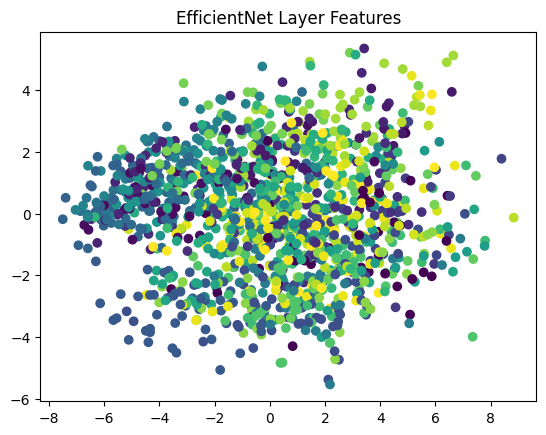

In [74]:
pca=PCA(n_components=2)

reduced=pca.fit_transform(features)

plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)

plt.title("EfficientNet Layer Features")

plt.show()